# Svingeligning

Kraftsystemer utsettes kontinuerlig for forstyrrelser som inn- og utkobling av last, kortslutninger, linjeutfall og generatorutfall. Slike hendelser skaper en midlertidig ubalanse mellom den mekaniske effekten som tilføres generatoren og den elektriske effekten som leveres til nettet.

Når denne balansen forstyrres, begynner rotorens lagrede kinetiske energi å endres. Rotoren kan enten akselerere eller bremse, noe som fører til at rotorvinkelen endrer seg over tid. Dersom rotorvinkelen blir for stor, kan generatoren miste synkronismen med resten av kraftsystemet.

Svingligningen beskriver denne dynamikken. Den kobler sammen effektubalanse, rotorens treghet og endringen i rotorvinkelen. Dermed gir den et matematisk grunnlag for å analysere hvordan en generator reagerer på forstyrrelser.

Svingligningen er derfor et av de viktigste verktøyene innen transient stabilitet. Den brukes til å avgjøre om en generator vil forbli synkron med nettet etter en feil, hvor raskt en feil må kobles ut, og hvordan systemets treghet påvirker stabiliteten.

Med andre ord beskriver svingligningen hvordan energien i rotorens roterende masse påvirker generatorens evne til å opprettholde synkron drift etter en forstyrrelse.

### Stasjonær drift
I normal stasjonær drift er den relative posisjonen mellom rotoraksen og aksen til det resulterende magnetfeltet konstant. Vinkelen mellom disse aksene kalles rotorvinkelen, $\delta_r$.

Det resulterende magnetfeltet er den vektorielle summen av rotorfeltet $F_r$ og statorfeltet $F_s$ i luftgapet. Feltet representerer den elektromagnetiske koblingen mellom rotor og stator, og rotorvinkelen $\delta_r$ måles som vinkelen mellom rotoraksen og aksen til dette resulterende feltet.

Ved lett belastning er $F_s$ liten, slik at det resulterende feltet nesten sammenfaller med rotorfeltet $F_r$. Ved høy belastning får statorfeltet større betydning, og den resulterende feltaksen flyttes.

Så lenge den mekaniske effekten som tilføres generatoren er lik den elektriske effekten som avgis til nettet, forblir rotorvinkelen $\delta_r$ konstant, og generatoren opererer synkront med kraftsystemet.

### Rotorvinkel og effektvinkel ved transient stabilitet

Rotorvinkelen $\delta_r$ er vinkelen mellom rotorfeltet $F_r$ og det resulterende luftgapfeltet $F_{sr}$

$$
\delta_r=\angle(F_r,F_{sr}).
$$

Effektvinkelen $\delta$ er vinkelen mellom den interne spenningen $E$ og terminalspenningen $V_t$

$$
\delta=\angle(E,V_t).
$$

I stasjonær drift er

$$
P_m=P_e,
$$

slik at både $\delta_r$ og $\delta$ er konstante. Ved en kortslutning reduseres den elektriske effekten raskt $P_e \downarrow$, 
mens den mekaniske effekten fra turbinen i første omgang er tilnærmet konstant, $P_m \approx \text{konstant}$.


### Ved kortslutning
Ved en kortslutning reduseres den elektriske effekten raskt

$$
P_e \downarrow .
$$

Årsaken er at den elektriske effekten som overføres til nettet er avhengig av spenningen ved generatorens terminaler. Når det oppstår en kortslutning i nettet, faller terminalspenningen kraftig. Dermed reduseres generatorens evne til å overføre aktiv effekt til kraftsystemet.

For en idealisert synkronmaskin er den elektriske effekten gitt av

$$
P_e=\frac{EV_t}{X_s}\sin\delta.
$$

Under en kortslutning blir terminalspenningen svært liten,

$$
V_t \downarrow ,
$$

og dermed reduseres også den elektriske effekten

$$
P_e \downarrow .
$$

Den mekaniske effekten fra turbinen endres derimot svært lite de første øyeblikkene etter feilen,

$$
P_m \approx \text{konstant}.
$$


### Effektoverskudd


Dermed oppstår et effektoverskudd

$$
P_a=P_m-P_e>0,
$$

som akselererer rotoren.

Den ekstra energien som turbinen tilfører kan ikke lenger overføres til nettet, men lagres midlertidig som kinetisk energi i den roterende massen. Rotoren begynner derfor å øke hastigheten, og rotorvinkelen vokser.

```text
Kortslutning
      ↓
Vt faller
      ↓
Pe faller
      ↓
Pa = Pm − Pe > 0
      ↓
Rotoren akselererer
      ↓
δr øker
      ↓
δ øker
```

Transient stabilitet handler derfor om hvorvidt generatoren klarer å gjenvinne balansen mellom $P_m$ og $P_e$ før rotorvinkelen blir så stor at synkronismen går tapt. 
Når

$$
P_m>P_e,
$$

oppstår en akselerasjonseffekt

$$
P_a=P_m-P_e.
$$

### Forflytning

Rotorfeltet $F_r$ flytter seg da relativt til luftgapfeltet $F_{sr}$, og rotorvinkelen øker

$$
\delta_r \uparrow.
$$

Siden den induserte spenningen $E$ følger rotorfeltet,

$$
E \perp F_r,
$$

vil også $E$ flytte seg. Dette fører til at effektvinkelen øker

$$
\delta \uparrow.
$$

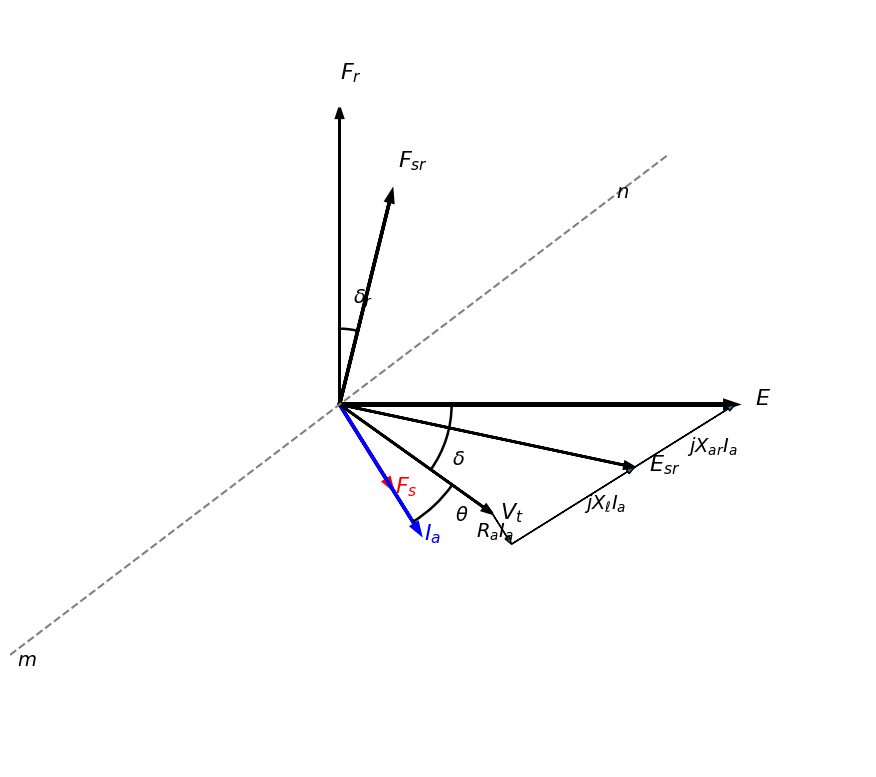

In [51]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

plt.rcParams["font.size"] = 14

# =====================================================
# Hjelpefunksjon
# =====================================================

def draw_vector(
    ax,
    start,
    vec,
    label,
    color="black",
    lw=2,
    label_scale=1.05,
):

    ax.arrow(
        start[0],
        start[1],
        vec[0],
        vec[1],
        head_width=0.10,
        head_length=0.15,
        length_includes_head=True,
        linewidth=lw,
        color=color,
    )

    end = start + vec

    ax.text(
        end[0] * label_scale,
        end[1] * label_scale,
        label,
        fontsize=16,
        color=color,
    )

# =====================================================
# Figur
# =====================================================

fig, ax = plt.subplots(figsize=(12, 8))

O = np.array([0.0, 0.0])

# =====================================================
# MMF-DIAGRAM
# =====================================================

Fr = np.array([0.0, 4.5])

fs_angle_deg = -58
fs_angle = np.deg2rad(fs_angle_deg)

Fs_mag = 1.5
Ia_mag = 2.3

Fs = Fs_mag * np.array([
    np.cos(fs_angle),
    np.sin(fs_angle)
])

Ia = Ia_mag * np.array([
    np.cos(fs_angle),
    np.sin(fs_angle)
])

Fsr = Fr + Fs

draw_vector(
    ax,
    O,
    Fr,
    r"$F_r$",
    label_scale=1.10
)

draw_vector(
    ax,
    O,
    Fs,
    r"$F_s$",
    color="red",
    lw=2.5
)

draw_vector(
    ax,
    O,
    Ia,
    r"$I_a$",
    color="blue",
    lw=2.5
)

draw_vector(
    ax,
    O,
    Fsr,
    r"$F_{sr}$",
    lw=2.5,
    label_scale=1.12
)

# =====================================================
# Rotorvinkel δr
# =====================================================

Fsr_angle = np.degrees(
    np.arctan2(Fsr[1], Fsr[0])
)

arc_dr = Arc(
    (0, 0),
    2.3,
    2.3,
    theta1=Fsr_angle,
    theta2=90,
    lw=1.8,
)

ax.add_patch(arc_dr)

ax.text(
    0.2,
    1.55,
    r"$\delta_r$"
)

# =====================================================
# m-n akse
# =====================================================

ax.plot(
    [-5, 5],
    [-3.8, 3.8],
    "--",
    color="gray",
    lw=1.5,
)

ax.text(-4.9, -3.95, r"$m$")
ax.text(4.2, 3.15, r"$n$")

# =====================================================
# SPENNINGSDIAGRAM
# =====================================================

# Fr -> E

E_mag = 6

E = np.array([
    E_mag,
    0.0
])

Ia_unit = Ia / np.linalg.norm(Ia)

# +j-retning

j_dir = np.array([
    -Ia_unit[1],
     Ia_unit[0]
])

# =====================================================
# Armaturreaksjon
# =====================================================

Xar_mag = 1.8

jXarIa = Xar_mag * j_dir

# E = Esr + jXarIa

Esr = E - jXarIa

# =====================================================
# Resistivt spenningsfall
# =====================================================

Ra_mag = 0.55

RaIa = Ra_mag * Ia_unit

# =====================================================
# Lekkreaktans
# =====================================================

Xl_mag = 2.2

jXlIa = Xl_mag * j_dir

# =====================================================
# Esr = Vt + RaIa + jXlIa
# =====================================================

Vt = Esr - RaIa - jXlIa

# =====================================================
# HOVEDFASORER
# =====================================================

draw_vector(
    ax,
    O,
    Vt,
    r"$V_t$"
)

draw_vector(
    ax,
    O,
    Esr,
    r"$E_{sr}$"
)

draw_vector(
    ax,
    O,
    E,
    r"$E$",
    lw=3
)

# =====================================================
# RaIa
# =====================================================

ax.arrow(
    Vt[0],
    Vt[1],
    RaIa[0],
    RaIa[1],
    head_width=0.08,
    head_length=0.12,
    length_includes_head=True,
)

ax.text(
    Vt[0] - 0.25,
    Vt[1] - 0.35,
    r"$R_aI_a$"
)

# =====================================================
# jXlIa
# =====================================================

xl_start = Vt + RaIa

ax.arrow(
    xl_start[0],
    xl_start[1],
    jXlIa[0],
    jXlIa[1],
    head_width=0.08,
    head_length=0.12,
    length_includes_head=True,
)

ax.text(
    xl_start[0] + 1.1,
    xl_start[1] + 0.55,
    r"$jX_{\ell}I_a$"
)

# =====================================================
# jXarIa
# =====================================================

ax.arrow(
    Esr[0],
    Esr[1],
    jXarIa[0],
    jXarIa[1],
    head_width=0.08,
    head_length=0.12,
    length_includes_head=True,
)

ax.text(
    Esr[0] + 0.8,
    Esr[1] + 0.25,
    r"$jX_{ar}I_a$"
)

# =====================================================
# δ
# =====================================================

vt_angle = np.degrees(
    np.arctan2(Vt[1], Vt[0])
)

arc_delta = Arc(
    (0, 0),
    3.4,
    3.4,
    theta1=vt_angle,
    theta2=0,
    lw=1.8,
)

ax.add_patch(arc_delta)

ax.text(
    1.7,
    -0.9,
    r"$\delta$"
)

# =====================================================
# θ
# =====================================================

arc_theta = Arc(
    (0, 0),
    4.2,
    4.2,
    theta1=fs_angle_deg,
    theta2=vt_angle,
    lw=1.8,
)

ax.add_patch(arc_theta)

ax.text(
    1.75,
    -1.75,
    r"$\theta$"
)

# =====================================================
# FORMAT
# =====================================================

ax.set_aspect("equal")

ax.set_xlim(-5, 8)
ax.set_ylim(-5.5, 6)

ax.axis("off")

plt.tight_layout()
plt.show()

### Akselerasjonseffekten

I stabil drift er det balanse mellom det mekaniske dreiemomentet fra turbinen og det elektromagnetiske dreiemomentet i generatoren

$$
\tau_m = \tau_e
$$

Dersom en forstyrrelse oppstår, blir denne balansen brutt. Forskjellen mellom det mekaniske og det elektromagnetiske dreiemomentet kalles akselerasjonsmomentet

$$
\tau_a = \tau_m - \tau_e
$$

Et positivt akselerasjonsmoment fører til at rotorhastigheten øker, mens et negativt akselerasjonsmoment fører til at rotorhastigheten reduseres.

Rotorens dynamiske bevegelse beskrives av svingeligningen

### Svingeligning

Vi tar utgangspunkt i Newtons 2. lov for roterende systemer:

$$
J\frac{d^2\theta_m}{dt^2}=\tau_a = \tau_m-\tau_e
$$

der $J$ er rotorens treghetsmoment, $\tau_m$ er mekanisk dreiemoment og $\tau_e$ er elektromagnetisk dreiemoment. $\theta_m$ er rotorens vinkel relativ til stator som roterer på synkronhastighet, $\omega_{sm}$:

$$\theta_m = \omega_{sm}t + \delta_m$$

der $\delta_m$ er posisjonen til rotor ved t=0, før forstyrrelsen.
Deriverer vi ligningen over får vi rotorens vinkelhastighet

$$\omega_m = \frac{d\theta_m}{dt} = \omega_{sm}t + \frac{d\delta_m}{dt}$$
    
Da er rotor akselerasjon den dobbeltderiverte

$$ \frac{d^2\theta_m}{dt^2} = \frac{d^2\delta_m}{dt^2}$$

Vi kan da sette den dobbeltderiverte inn i Newtons 2. lov:

$$J\frac{d\delta_m^2}{dt^2} = \tau_m - \tau_e$$

og deretter multiplisere med rotorhastighet ($\omega_m$):

$$J\omega_m\frac{d\delta_m^2}{dt^2} = \omega_m\tau_m - \omega_m\tau_e$$

Siden kraft er rotorhastighet ganger dreiemoment får vi et utrrykk med effekt:

$$J\omega_m\frac{d\delta_m^2}{dt^2} = P_m - P_e$$

$J\omega_m$ er treghetskonstanten (inertia constant) og blir ofte kalt M, som er relatert til kinetisk energi i roterende masse, $W_k$:

$$W_k = \frac{1}{2}J\omega_m^2 = \frac{1}{2}M\omega_m $$

Deler vi Wk på systembasen får vi H som er treghetskonstanten per enhet:

$$ H = \frac{\text{Kinetisk energi i MJ ved nominell hastighet}}{\text{Nominell effekt}} = \frac{W_k}{S_{N}} $$

Vi får også $M = \frac{2W_k}{\omega_{m}}$. Selv om $M = J\omega_m$ egentlig varierer med rotorhastigheten, er hastighetsavvikene under stabilitetsforløpet så små at vi setter $\omega_m \approx \omega_{sm}$ og behandler M som en konstant: $M = \frac{2W_k}{\omega_{sm}}$ 

Da får vi en enklere ligning:

$$
M\frac{d^2\delta}{dt^2}=P_m-P_e
$$


Uttrykt på effektform og i per unit skrives svingeligningen ofte som

$$
\frac{2H}{\omega_s}\frac{d^2\delta}{dt^2}=P_m-P_e
$$

der $H$ er treghetskonstanten, $\omega_s$ er synkron vinkelhastighet, og $\delta$ er rotorvinkelen målt i forhold til det synkront roterende referansesystemet.

Svingeligningen er den grunnleggende ligningen for analyse av transient stabilitet. Den beskriver hvordan rotorvinkelen utvikler seg etter en forstyrrelse, og gjør det mulig å avgjøre om generatoren vil forbli i synkronisme med kraftsystemet eller miste synkronismen.